In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import sys
import gc

# Change root directory to the repo root (Jupyter: __file__ is not defined)
def find_repo_root(start=Path.cwd()):
	for p in [start] + list(start.parents):
		if (p / 'Code').exists() or (p / '.git').exists() or (p / 'local_repo').exists():
			return p
	return start

repo_root = find_repo_root()
data_root = repo_root.parent.parent / 'Data' / 'CBOS ready'
out_root = repo_root.parent.parent / 'Data' / 'reweighing'

os.chdir(repo_root)
sys.path.append(str(repo_root / 'Code' / 'tools'))

In [2]:
df = pd.read_csv(data_root / 'CBOS_data_imputed.csv')
print(f"Loaded: {df.shape[0]:,} obs × {df.shape[1]} cols, {df['survey_file'].nunique()} surveys")
# Construct survey date from survey_month and survey_year
df['survey_date'] = pd.to_datetime(df['survey_year'].astype(str) + '-' + df['survey_month'].astype(str).str.zfill(2) + '-01')


/var/folders/y8/4_9g68pj7k136q2yypgp5ysc0000gn/T/ipykernel_35987/3642088531.py:1: DtypeWarning: Columns (15,16,21,27,28,29,33,34,35,40,41,45,46,47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_root / 'CBOS_data_imputed.csv')


Loaded: 355,337 obs × 70 cols, 327 surveys


In [3]:
# Create a thresholded variables for "age"

df['age_1990'] = np.nan
df['age_1990_L'] = ""

df['age_2000'] = np.nan
df['age_2000_L'] = ""

df['hh_size_1990'] = np.nan
df['hh_size_1990_L'] = ""

df['hh_size_2000'] = np.nan
df['hh_size_2000_L'] = ""

for idx, row in df.iterrows():
    age = row['age']
    if age in [0,1,2,3,4]:
        df.at[idx, 'age_2000'] = 1
        df.at[idx, 'age_2000_L'] = "0-4"
        df.at[idx, 'age_1990'] = 1
        df.at[idx, 'age_1990_L'] = "0-9"
    elif age in [5,6,7,8,9]:
        df.at[idx, 'age_2000'] = 2
        df.at[idx, 'age_2000_L'] = "5-9"
        df.at[idx, 'age_1990'] = 1
        df.at[idx, 'age_1990_L'] = "0-9"
    elif age in [10,11,12,13,14]:
        df.at[idx, 'age_2000'] = 3
        df.at[idx, 'age_2000_L'] = "10-14"
        df.at[idx, 'age_1990'] = 2
        df.at[idx, 'age_1990_L'] = "10-19"
    elif age in [15,16,17,18,19]:
        df.at[idx, 'age_2000'] = 4
        df.at[idx, 'age_2000_L'] = "15-19"
        df.at[idx, 'age_1990'] = 2
        df.at[idx, 'age_1990_L'] = "10-19"
    elif age in [20,21,22,23,24]:
        df.at[idx, 'age_2000'] = 5
        df.at[idx, 'age_2000_L'] = "20-24"
        df.at[idx, 'age_1990'] = 3
        df.at[idx, 'age_1990_L'] = "20-29"
    elif age in [25,26,27,28,29]:
        df.at[idx, 'age_2000'] = 6
        df.at[idx, 'age_2000_L'] = "25-29"
        df.at[idx, 'age_1990'] = 3
        df.at[idx, 'age_1990_L'] = "20-29"
    elif age in [30,31,32,33,34]:
        df.at[idx, 'age_2000'] = 7
        df.at[idx, 'age_2000_L'] = "30-34"
        df.at[idx, 'age_1990'] = 4
        df.at[idx, 'age_1990_L'] = "30-39"
    elif age in [35,36,37,38,39]:
        df.at[idx, 'age_2000'] = 8
        df.at[idx, 'age_2000_L'] = "35-39"
        df.at[idx, 'age_1990'] = 4
        df.at[idx, 'age_1990_L'] = "30-39"
    elif age in [40,41,42,43,44]:
        df.at[idx, 'age_2000'] = 9
        df.at[idx, 'age_2000_L'] = "40-44"
        df.at[idx, 'age_1990'] = 5
        df.at[idx, 'age_1990_L'] = "40-49"
    elif age in [45,46,47,48,49]:
        df.at[idx, 'age_2000'] = 10
        df.at[idx, 'age_2000_L'] = "45-49"
        df.at[idx, 'age_1990'] = 5
        df.at[idx, 'age_1990_L'] = "40-49"
    elif age in [50,51,52,53,54]:
        df.at[idx, 'age_2000'] = 11
        df.at[idx, 'age_2000_L'] = "50-54"
        df.at[idx, 'age_1990'] = 6
        df.at[idx, 'age_1990_L'] = "50-59"
    elif age in [55,56,57,58,59]:
        df.at[idx, 'age_2000'] = 12
        df.at[idx, 'age_2000_L'] = "55-59"
        df.at[idx, 'age_1990'] = 6
        df.at[idx, 'age_1990_L'] = "50-59"
    elif age in [60,61,62,63,64]:
        df.at[idx, 'age_2000'] = 13
        df.at[idx, 'age_2000_L'] = "60-64"
        df.at[idx, 'age_1990'] = 7
        df.at[idx, 'age_1990_L'] = "60 lat i więcej"
    elif age in [65,66,67,68,69]:
        df.at[idx, 'age_2000'] = 14
        df.at[idx, 'age_2000_L'] = "65-69"
        df.at[idx, 'age_1990'] = 7
        df.at[idx, 'age_1990_L'] = "60 lat i więcej"
    else:
        df.at[idx, 'age_2000'] = 15
        df.at[idx, 'age_2000_L'] = "70 i więcej"
        df.at[idx, 'age_1990'] = 7
        df.at[idx, 'age_1990_L'] = "60 lat i więcej"
    
    hh_size = row['household_size']
    if hh_size == 1.0:
        df.at[idx, 'hh_size_2000'] = 1
        df.at[idx, 'hh_size_2000_L'] = "1-osobowe"
        df.at[idx, 'hh_size_1990'] = 1
        df.at[idx, 'hh_size_1990_L'] = "1-osobowe"
    elif hh_size == 2.0:
        df.at[idx, 'hh_size_2000'] = 2
        df.at[idx, 'hh_size_2000_L'] = "2-osobowe"
        df.at[idx, 'hh_size_1990'] = 2
        df.at[idx, 'hh_size_1990_L'] = "2-osobowe"
    elif hh_size == 3.0:
        df.at[idx, 'hh_size_2000'] = 3
        df.at[idx, 'hh_size_2000_L'] = "3-osobowe"
        df.at[idx, 'hh_size_1990'] = 3
        df.at[idx, 'hh_size_1990_L'] = "3-4-osobowe"
    elif hh_size == 4.0:
        df.at[idx, 'hh_size_2000'] = 4
        df.at[idx, 'hh_size_2000_L'] = "4-osobowe"
        df.at[idx, 'hh_size_1990'] = 3
        df.at[idx, 'hh_size_1990_L'] = "3-4-osobowe"
    else:
        df.at[idx, 'hh_size_2000'] = 5
        df.at[idx, 'hh_size_2000_L'] = "5 i więcej-osobowe"
        df.at[idx, 'hh_size_1990'] = 4
        df.at[idx, 'hh_size_1990_L'] = "5 i więcej-osobowe"

In [4]:
import geoTERYT_db as gtdb
geo_root = data_root.parent / 'Geospatial'
complete_db_path = geo_root / 'geoteryt_E.pkl'
db = gtdb.load_complete_database(complete_db_path)
gc.collect()

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_E.pkl...
  Database version: 4.3
  ✓ Restored old voivodships: 49 rows
  ✓ Restored geometry store: 13,287 unique geometries
  ✓ Restored geometry data for years: [2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2015, 2016, 2017, 2018, 2021, 2022, 2023]
  ✓ Loaded 4613 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 3662
  ✓ Records with old_woj: 4104
  ✓ Records with data: 4592
  ✓ Records with cross tables: 4592
  ✓ Records with population data: 4590
  ✓ Records with pop_class: 4542


0

In [5]:
def find_old_voiv_teryt_id(name):
    for id in range(1,50):
        rec = db.get_by_teryt_id(f'{100-id}00000')
        if name.lower().strip() in rec.name.lower().strip():
            return rec.teryt_id
    return None

def find_new_voiv_teryt_id(name):
    for id in range(2,34,2):
        rec = db.get_by_teryt_id(f'{str(id).zfill(2)}00000')
        if name.lower().strip() in rec.name.lower().strip():
            return rec.teryt_id
    return None
# Test:
print(find_old_voiv_teryt_id('warszawskie'))
print(db.get_by_teryt_id(find_old_voiv_teryt_id('warszawskie')))

5800000
TERYTRecord(5800000, Warszawskie, years=None-None, no changes)


In [6]:
df['teryt_id_VOIV'] = ""
for idx, row in df.iterrows():
    new_voiv = row['location_new']
    old_voiv = row['location_old']
    if not np.isnan(new_voiv):
        try:
            df.at[idx, 'teryt_id_VOIV'] = find_new_voiv_teryt_id(row['location_new_L'])
        except:
            continue
    if not np.isnan(old_voiv):
        try:
            df.at[idx, 'teryt_id_VOIV'] = find_old_voiv_teryt_id(row['location_old_L'])
        except:
            continue

In [7]:
def find_teryts_in_pop_threshold(children: list, year: int, lower_bound: int= None, upper_bound: int = None):
    if lower_bound is None:
        raise ValueError("Lower bound cannot be None.")
    if upper_bound is None:
        upper_bound = float('inf')
    if lower_bound > upper_bound:
        raise ValueError("Lower bound cannot be greater than upper bound.")
    locations = []
    new_children = []
    
    if np.any([child.endswith('0') for child in children]):
        for child in children:
            if child.endswith(('1','2','3')):
                new_children.append(child)
            else:
                new_children.extend([child for child in db.get_by_teryt_id(child).children_ids[year] if child.endswith(('1','2','3'))])
    else:
        new_children = children

    for child in new_children:
        if child.endswith('1'):
            rec = db.get_by_teryt_id(child)
            pop = rec.est_pop
            if pop.loc[pop.index.year == year].values[0] >= lower_bound and pop.loc[pop.index.year == year].values[0] <= upper_bound:
                locations.append(child)
    return new_children, locations

def find_the_rest_of_teryts(complementary_list: list, children: list):
    return [child for child in children if child not in complementary_list]

In [8]:
def create_teryt_id_VOIV_(voiv, cs, year, type):
    if type == '500':
        all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 500_000, None)
        if cs == 5.0:                   # City >500k
            return children_in_threshold
        else:
            return find_the_rest_of_teryts(children_in_threshold, all_gminas)
    elif type == '100-200-500':
        if cs == 6.0:                   # City >500k
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 500_000, None)
            return children_in_threshold
        elif cs == 5.0:                 # City 100k-500k
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 200_000, 500_000)
            return children_in_threshold
        elif cs == 4.0:
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 100_000, 200_000)
            return children_in_threshold
        else:
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 100_000, None)
            return find_the_rest_of_teryts(children_in_threshold, all_gminas)
    elif type == '100-500':
        if cs == 5.0:                   # City >500k
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 500_000, None)
            return children_in_threshold
        elif cs == 4.0:                 # City 100k-500k
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 100_000, 500_000)
            return children_in_threshold
        else:
            all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 100_000, None)
            return find_the_rest_of_teryts(children_in_threshold, all_gminas)
    elif type == '100':
        all_gminas, children_in_threshold = find_teryts_in_pop_threshold(db.get_by_teryt_id(voiv).children_ids[year], year, 100_000, None)
        if cs == 5.0:                 # City >500k
            return children_in_threshold
        if cs == 4.0:                 # City 100k-500k
            return children_in_threshold
        else:
            return find_the_rest_of_teryts(children_in_threshold, all_gminas)
    else:
        raise ValueError("Type must be either '500' or '100'.")


In [9]:
new_voiv_dict = {}
for id in range(2,34,2):
    rec = db.get_by_teryt_id(f"{str(id).zfill(2)}00000")
    voiv_dict = {}
    for year in range(1986, 2025):
        year_dict = {}
        for type in ['500', '100-200-500', '100-500', '100']:
            type_dict = {}
            cs_iterate = [1.0, 2.0, 3.0, 4.0, 5.0]
            if type == "100-200-500":
                cs_iterate.append(6.0)
            for cs in cs_iterate:
                type_dict[cs] = create_teryt_id_VOIV_(f"{str(id).zfill(2)}00000", cs, year, type)
            year_dict[type] = type_dict
        voiv_dict[year] = year_dict
    new_voiv_dict[f"{str(id).zfill(2)}00000"] = voiv_dict
    
old_voiv_dict = {}
for id in range(1,50):
    rec = db.get_by_teryt_id(f"{100-id}00000")
    voiv_dict = {}
    for year in range(1986, 2025):
        year_dict = {}
        for type in ['500', '100-200-500', '100-500', '100']:
            type_dict = {}
            cs_iterate = [1.0, 2.0, 3.0, 4.0, 5.0]
            if type == "100-200-500":
                cs_iterate.append(6.0)
            for cs in cs_iterate:
                type_dict[cs] = create_teryt_id_VOIV_(f"{100-id}00000", cs, year, type)
            year_dict[type] = type_dict
        voiv_dict[year] = year_dict
    old_voiv_dict[f"{100-id}00000"] = voiv_dict
    
# Schema: new_voiv_dict[voiv][year][type][cs] -> list of teryt_ids
gc.collect()

0

In [10]:
for year in range(1986, 2025):
    for type in ['500', '100-200-500', '100-500', '100']:
        cs_iterate = [1.0, 2.0, 3.0, 4.0, 5.0]
        if type == "100-200-500":
            cs_iterate.append(6.0)
        for cs in cs_iterate:
            if "1431001" in new_voiv_dict['1400000'][year][type][cs]:
                # change for 1465011
                new_voiv_dict['1400000'][year][type][cs] = [id if id != "1431001" else "1465011" for id in new_voiv_dict['1400000'][year][type][cs]]

In [11]:
### LIS
lis_macroregions = {1: ['5800000', '9400000', '7500000', '6900000', '6700000'],
                    2: ['9800000', '5200000', '7700000', '6400000'],
                    3: ['9200000', '9100000', '8400000', '6200000', '6300000'],
                    4: ['9700000', '9300000', '8700000', '7600000'],
                    5: ['8600000', '8300000', '8200000', '7800000', '7100000', '6800000', '6100000', '6000000'],
                    6: ['9900000', '9500000', '7900000', '5400000'],
                    7: ['5100000', '7300000', '7000000', '6600000', '6500000'],
                    8: ['9600000', '8800000', '8500000', '8000000', '7400000', '7200000', '5900000', '5500000'],
                    9: ['9000000', '8900000', '8100000', '5700000', '5600000', '5300000']
                    }
lis_macroregions_dict = {}

# Join the codes form old_voiv_dict according to the macroregions
for macroregion, voivs in lis_macroregions.items():
    macroregion_dict = {}
    for year in range(1986, 2025):
        year_dict = {}
        for type in ['500', '100-200-500', '100-500', '100']:
            type_dict = {}
            cs_iterate = [1.0, 2.0, 3.0, 4.0, 5.0]
            if type == "100-200-500":
                cs_iterate.append(6.0)
            for cs in cs_iterate:
                teryt_ids = []
                for voiv in voivs:
                    teryt_ids.extend(old_voiv_dict[voiv][year][type][cs])
                type_dict[cs] = teryt_ids
            year_dict[type] = type_dict
        macroregion_dict[year] = year_dict
    lis_macroregions_dict[macroregion] = macroregion_dict

### CBOS
cbos_macroregions = {1: ['1400000', '1000000'],
                     2: ['1200000', '2400000'],
                     3: ['0600000', '1800000', '2000000', '2600000'],
                     4: ['3000000', '3200000', '0800000'],
                     5: ['0200000', '1600000'],
                     6: ['2200000', '2800000', '0400000']
                     }

# Join the codes form new_voiv_dict according to the macroregions
cbos_macroregions_dict = {}
for macroregion, voivs in cbos_macroregions.items():
    macroregion_dict = {}
    for year in range(1986, 2025):
        year_dict = {}
        for type in ['500', '100-200-500', '100-500', '100']:
            type_dict = {}
            cs_iterate = [1.0, 2.0, 3.0, 4.0, 5.0]
            if type == "100-200-500":
                cs_iterate.append(6.0)
            for cs in cs_iterate:
                teryt_ids = []
                for voiv in voivs:
                    teryt_ids.extend(new_voiv_dict[voiv][year][type][cs])
                type_dict[cs] = teryt_ids
            year_dict[type] = type_dict
        macroregion_dict[year] = year_dict
    cbos_macroregions_dict[macroregion] = macroregion_dict

gc.collect()


0

In [12]:
for idx, row in df.iterrows():
    if row['teryt_id_VOIV'] == '':
        df.at[idx, 'teryt_id_VOIV'] = cbos_macroregions[row['location_new']]

In [13]:
def create_teryt_id_VOIV(row, type):
    voiv = row['teryt_id_VOIV']
    cs = row['cs']
    if np.isnan(cs):
        return None
    year = row['survey_date'].year
    
    if voiv in list(cbos_macroregions.values()):
        return cbos_macroregions_dict[int(row['location_new'])][year][type][cs]
    
    if voiv in new_voiv_dict.keys():
        return new_voiv_dict[voiv][year][type][cs]
    elif voiv in old_voiv_dict.keys():
        return old_voiv_dict[voiv][year][type][cs]
    else:
        return None

df['teryt_id_VOIV_500'] = df.apply(lambda row: create_teryt_id_VOIV(row, '500'), axis=1)
df['teryt_id_VOIV_100_500'] = df.apply(lambda row: create_teryt_id_VOIV(row, '100-500'), axis=1)
df['teryt_id_VOIV_100'] = df.apply(lambda row: create_teryt_id_VOIV(row, '100'), axis=1)


In [14]:
problematic_cs = df[df['teryt_id_VOIV_100_500'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)]
gc.collect()

0

In [ ]:
df['cs_prob'] = df['cs']

for idx, row in problematic_cs.iterrows():
    df.at[idx, 'cs_prob'] = np.nan

In [15]:
import collections

U_old_voiv_dict = {}
U_new_voiv_dict = {}
U_lis_macroregions_dict = {}
U_cbos_macroregions_dict = {}

i=1
for voiv in old_voiv_dict.keys():
    for year in old_voiv_dict[voiv].keys():
        for type in old_voiv_dict[voiv][year].keys():
            for cs in old_voiv_dict[voiv][year][type].keys():
                key = (voiv, year, type, cs)
                array = old_voiv_dict[voiv][year][type][cs]
                the_same_arrays = [key]
                already_seen = False
                if len(U_old_voiv_dict) > 0:
                    for id in U_old_voiv_dict.keys():
                        if key in U_old_voiv_dict[id]['keys']:
                            the_same_arrays = U_old_voiv_dict[id]['keys']
                            already_seen = True
                            break
                if not already_seen:
                    for other_voiv in old_voiv_dict.keys():
                        for other_year in old_voiv_dict[other_voiv].keys():
                            for other_type in old_voiv_dict[other_voiv][other_year].keys():
                                for other_cs in old_voiv_dict[other_voiv][other_year][other_type].keys():
                                    other_key = (other_voiv, other_year, other_type, other_cs)
                                    other_array = old_voiv_dict[other_voiv][other_year][other_type][other_cs]
                                    if collections.Counter(array) == collections.Counter(other_array):
                                        the_same_arrays.append(other_key)
                    U_old_voiv_dict[f'Group {i}'] = {'keys': the_same_arrays, 'array': array}
                    i+=1

i=1
for voiv in new_voiv_dict.keys():
    for year in new_voiv_dict[voiv].keys():
        for type in new_voiv_dict[voiv][year].keys():
            for cs in new_voiv_dict[voiv][year][type].keys():
                key = (voiv, year, type, cs)
                array = new_voiv_dict[voiv][year][type][cs]
                the_same_arrays = [key]
                already_seen = False
                if len(U_new_voiv_dict) > 0:
                    for id in U_new_voiv_dict.keys():
                        if key in U_new_voiv_dict[id]['keys']:
                            the_same_arrays = U_new_voiv_dict[id]['keys']
                            already_seen = True
                            break
                if not already_seen:
                    for other_voiv in new_voiv_dict.keys():
                        for other_year in new_voiv_dict[other_voiv].keys():
                            for other_type in new_voiv_dict[other_voiv][other_year].keys():
                                for other_cs in new_voiv_dict[other_voiv][other_year][other_type].keys():
                                    other_key = (other_voiv, other_year, other_type, other_cs)
                                    other_array = new_voiv_dict[other_voiv][other_year][other_type][other_cs]
                                    if collections.Counter(array) == collections.Counter(other_array):
                                        the_same_arrays.append(other_key)
                    U_new_voiv_dict[f'Group {i}'] = {'keys': the_same_arrays, 'array': array}
                    i+=1

i=1
for macroregion in lis_macroregions_dict.keys():
    for year in lis_macroregions_dict[macroregion].keys():
        for type in lis_macroregions_dict[macroregion][year].keys():
            for cs in lis_macroregions_dict[macroregion][year][type].keys():
                key = (macroregion, year, type, cs)
                array = lis_macroregions_dict[macroregion][year][type][cs]
                the_same_arrays = [key]
                already_seen = False
                if len(U_lis_macroregions_dict) > 0:
                    for id in U_lis_macroregions_dict.keys():
                        if key in U_lis_macroregions_dict[id]['keys']:
                            the_same_arrays = U_lis_macroregions_dict[id]['keys']
                            already_seen = True
                            break
                if not already_seen:
                    for other_macroregion in lis_macroregions_dict.keys():
                        for other_year in lis_macroregions_dict[other_macroregion].keys():
                            for other_type in lis_macroregions_dict[other_macroregion][other_year].keys():
                                for other_cs in lis_macroregions_dict[other_macroregion][other_year][other_type].keys():
                                    other_key = (other_macroregion, other_year, other_type, other_cs)
                                    other_array = lis_macroregions_dict[other_macroregion][other_year][other_type][other_cs]
                                    if collections.Counter(array) == collections.Counter(other_array):
                                        the_same_arrays.append(other_key)
                    U_lis_macroregions_dict[f'Group {i}'] = {'keys': the_same_arrays, 'array': array}
                    i+=1

i=1
for macroregion in cbos_macroregions_dict.keys():
    for year in cbos_macroregions_dict[macroregion].keys():
        for type in cbos_macroregions_dict[macroregion][year].keys():
            for cs in cbos_macroregions_dict[macroregion][year][type].keys():
                key = (macroregion, year, type, cs)
                array = cbos_macroregions_dict[macroregion][year][type][cs]
                the_same_arrays = [key]
                already_seen = False
                if len(U_cbos_macroregions_dict) > 0:
                    for id in U_cbos_macroregions_dict.keys():
                        if key in U_cbos_macroregions_dict[id]['keys']:
                            the_same_arrays = U_cbos_macroregions_dict[id]['keys']
                            already_seen = True
                            break
                if not already_seen:
                    for other_macroregion in cbos_macroregions_dict.keys():
                        for other_year in cbos_macroregions_dict[other_macroregion].keys():
                            for other_type in cbos_macroregions_dict[other_macroregion][other_year].keys():
                                for other_cs in cbos_macroregions_dict[other_macroregion][other_year][other_type].keys():
                                    other_key = (other_macroregion, other_year, other_type, other_cs)
                                    other_array = cbos_macroregions_dict[other_macroregion][other_year][other_type][other_cs]
                                    if collections.Counter(array) == collections.Counter(other_array):
                                        the_same_arrays.append(other_key)
                    U_cbos_macroregions_dict[f'Group {i}'] = {'keys': the_same_arrays, 'array': array}
                    i+=1


Index(['Unnamed: 0', 'org_id', 'survey_file', 'survey_year', 'survey_month',
       'age', 'year_born', 'sex', 'sex_L', 'city_size', 'city_size_L',
       'education', 'education_L', 'location_new', 'location_old',
       'location_new_L', 'location_old_L', 'household_size', 'job_type',
       'job_type_L', 'employment_status', 'employment_status_L', 'sol',
       'sol_L', 'income_hh_OLD', 'income_hh_NEW', 'income_hh',
       'income_hh_OLD_L', 'income_hh_NEW_L', 'income_hh_L', 'income_hh_OLD_T',
       'income_hh_NEW_T', 'income_hh_T', 'income_hh_OLD_T_L',
       'income_hh_NEW_T_L', 'income_hh_T_L', 'income_p_OLD', 'income_p_NEW',
       'income_p', 'income_p_OLD_L', 'income_p_NEW_L', 'income_p_L',
       'income_p_OLD_T', 'income_p_NEW_T', 'income_p_T', 'income_p_OLD_T_L',
       'income_p_NEW_T_L', 'income_p_T_L', 'weight', 'cs', 'cs_L', 'educ_1990',
       'educ_2000', 'educ_1990_L', 'educ_2000_L', 'income_hh_OLD_IM',
       'income_hh_NEW_IM', 'income_p_OLD_IM', 'income_p_NEW_IM'

In [16]:
# Dump the dictionaries to files as json
import json

out_root = repo_root.parent.parent / 'Data' / 'reweighing'

with open(out_root / 'U_old_voiv_dict.json', 'w') as f:
    json.dump(U_old_voiv_dict, f)
with open(out_root / 'U_new_voiv_dict.json', 'w') as f:
    json.dump(U_new_voiv_dict, f)
with open(out_root / 'U_lis_macroregions_dict.json', 'w') as f:
    json.dump(U_lis_macroregions_dict, f)
with open(out_root / 'U_cbos_macroregions_dict.json', 'w') as f:
    json.dump(U_cbos_macroregions_dict, f)

In [17]:
# Region dictionaries:
from local_utility_functions import remove_polish_characters

old_voiv_region_dict = {}
for id in range(1,50):
    rec = db.get_by_teryt_id(f'{100-id}00000')
    old_voiv_region_dict[f'{100-id}00000'] = remove_polish_characters(str(rec.name).lower().strip())
new_voiv_region_dict = {}
for id in range(2,34,2):
    rec = db.get_by_teryt_id(f'{str(id).zfill(2)}00000')
    new_voiv_region_dict[f'{str(id).zfill(2)}00000'] = remove_polish_characters(str(rec.name).lower().strip())

# Dump the dictionaries to files as json
with open(out_root.parent / 'old_voiv_region_dict.json', 'w', encoding='utf-8') as f:
    json.dump(old_voiv_region_dict, f, ensure_ascii=False)
with open(out_root.parent / 'new_voiv_region_dict.json', 'w', encoding='utf-8') as f:
    json.dump(new_voiv_region_dict, f, ensure_ascii=False)

In [18]:
# Series of box plots for each survey_month and survey_year for column weight:

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(30, 6)) 
sns.boxplot(x='survey_date', y='weight', data=df)
plt.title('Box Plot of Weights by Survey Year')
plt.xlabel('Survey Year')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


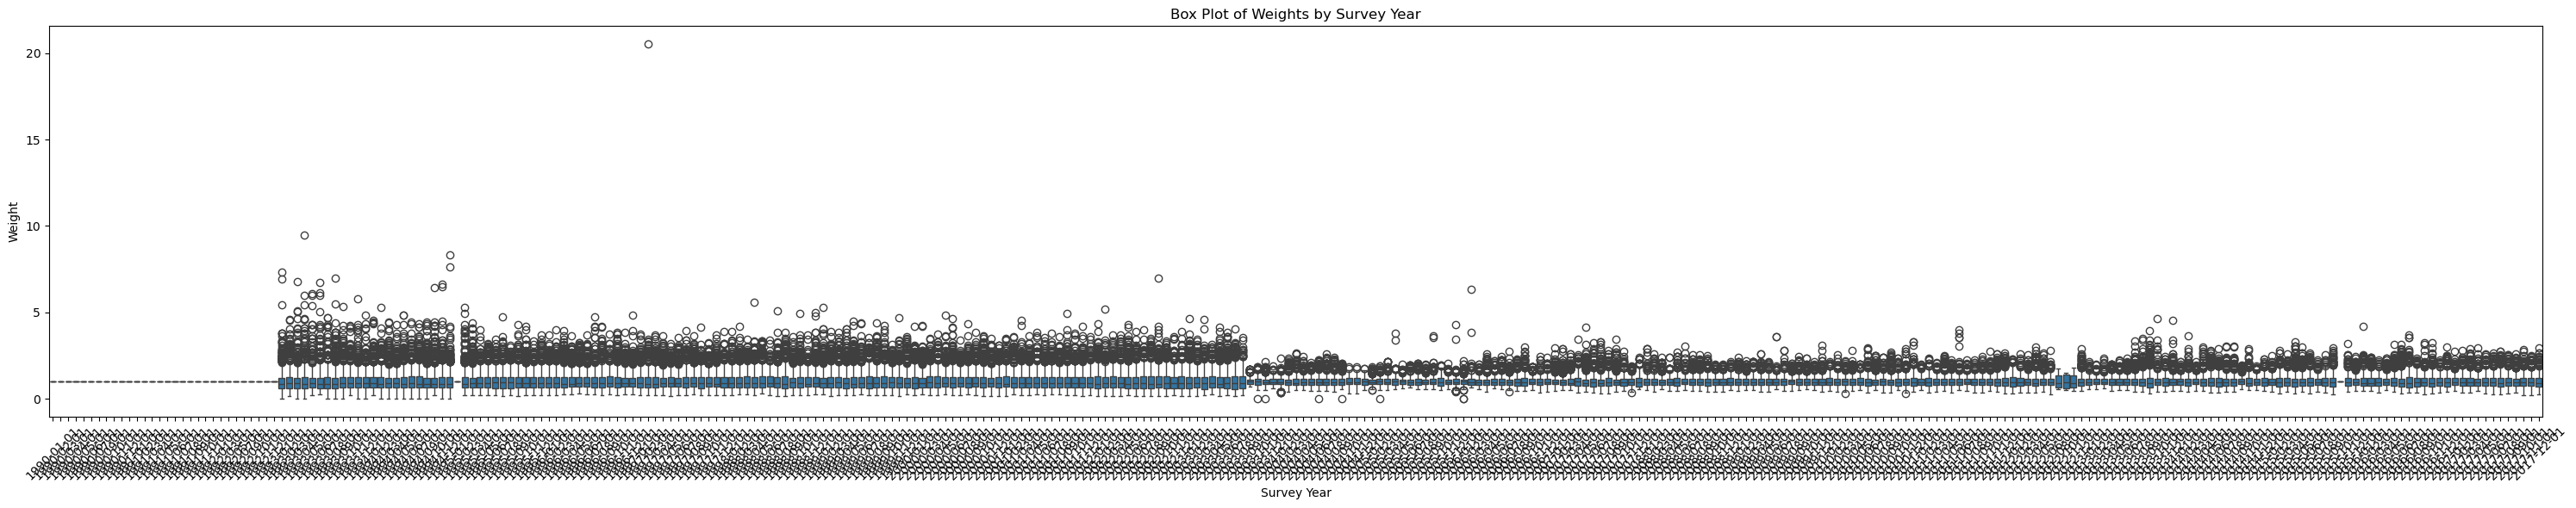

In [19]:
df['weight_VOIV'] = df['weight']
df['weight_VOIV_500'] = df['weight']
df['weight_VOIV_100_500'] = df['weight']
df['weight_VOIV_100'] = df['weight']

In [20]:
df.to_csv(data_root / 'CBOS_data_to_weight.csv', index=False)